# Term Deposit Subscription Prediction (Bank Marketing)

## Objective
Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign using Machine Learning models.

## Tasks Covered
- Load and explore dataset
- Encode categorical features
- Train Logistic Regression and Random Forest models
- Evaluate models using:
  - Confusion Matrix
  - F1-Score
  - ROC Curve
- Explain predictions using SHAP (Explainable AI)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    auc
)

warnings.filterwarnings('ignore')

C:\Users\RAYYAN\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load Dataset
file_path = "Bank Marketing Dataset (UCI).xlsx"

df = pd.read_excel(file_path)

print("Original Dataset Shape:", df.shape)

# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

# Display first 5 rows
df.head()

Original Dataset Shape: (41188, 21)
Dataset Shape After Removing Duplicates: (41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Dataset Information

In [3]:
print(df.info())

# Statistical Summary
display(df.describe())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  str    
 2   marital         41176 non-null  str    
 3   education       41176 non-null  str    
 4   default         41176 non-null  str    
 5   housing         41176 non-null  str    
 6   loan            41176 non-null  str    
 7   contact         41176 non-null  str    
 8   month           41176 non-null  str    
 9   day_of_week     41176 non-null  str    
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  str    
 15  emp_var_rate    41176 non-null  float64
 16  cons_price_idx  41176 non-null  float64
 17  cons_conf_idx   41176 non-null  float64
 18  eu

,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



Missing Values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64


# Encode Target Variable

In [4]:
label_encoder = LabelEncoder()

df['y'] = label_encoder.fit_transform(df['y'])

# yes = 1, no = 0
print(df['y'].value_counts())

# Features and Target
X = df.drop('y', axis=1)
y = df['y']

# Identify Categorical and Numerical Columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

y
0    36537
1     4639
Name: count, dtype: int64

Categorical Columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

Numerical Columns:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
      dtype='str')


# Data Preprocessing Pipelines

In [5]:
# Numerical Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Both Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print("Preprocessing Pipeline Created Successfully")

Preprocessing Pipeline Created Successfully


# Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (32940, 20)
Testing Data Shape: (8236, 20)


## Exploratory Data Analysis

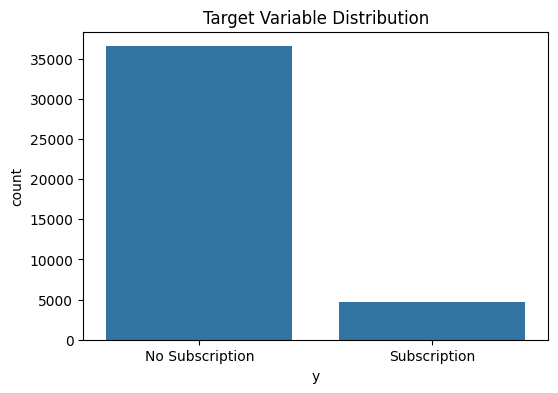

In [7]:
# Target Variable Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)

plt.title('Target Variable Distribution')
plt.xticks([0,1], ['No Subscription', 'Subscription'])

plt.show()

### Age Distribution

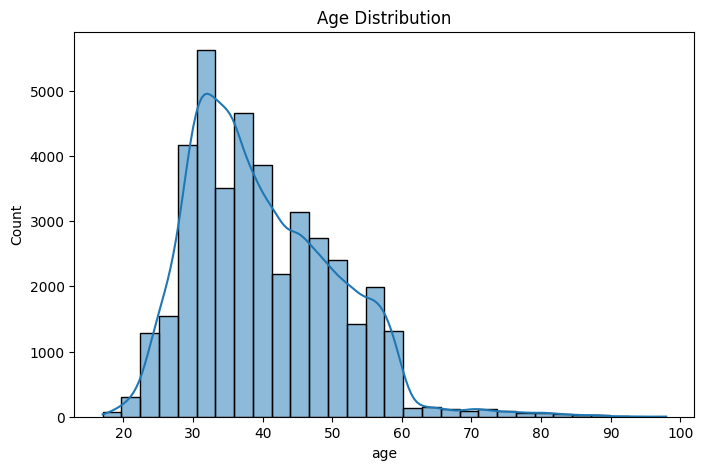

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)

plt.title('Age Distribution')

plt.show()

### Job Distribution

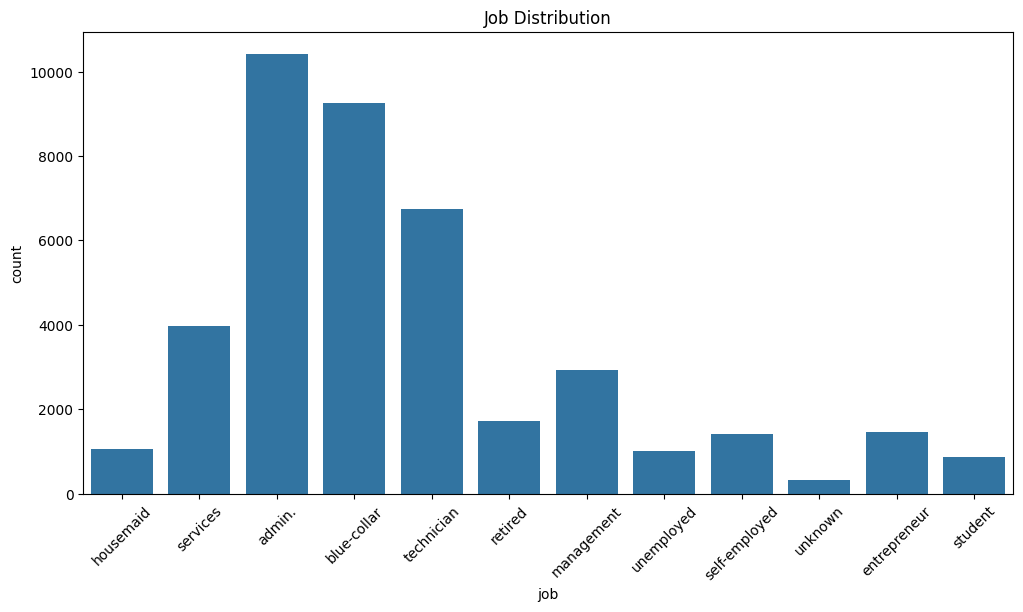

In [9]:
plt.figure(figsize=(12,6))
sns.countplot(x='job', data=df)

plt.xticks(rotation=45)
plt.title('Job Distribution')

plt.show()

### Correlation Heatmap

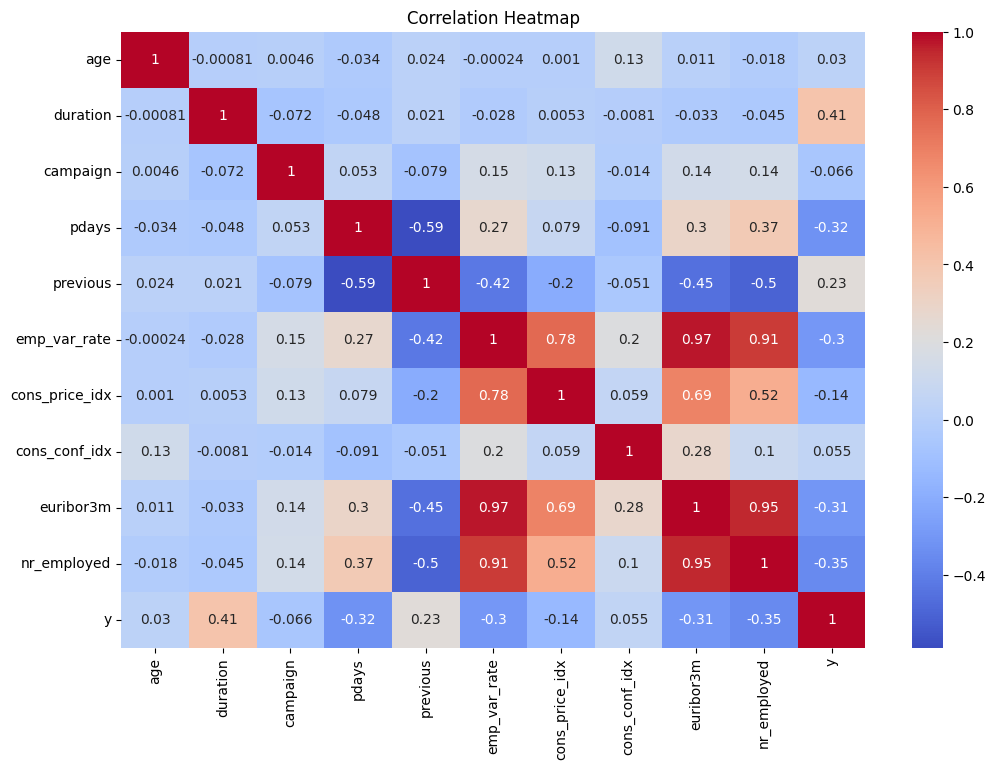

In [10]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

## Logistic Regression Model

In [11]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

# Train Model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:,1]

# Evaluation
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

F1 Score: 0.6012838801711841

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7308
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8236
   macro avg       0.72      0.88      0.76      8236
weighted avg       0.93      0.86      0.88      8236



### Logistic Regression Confusion Matrix

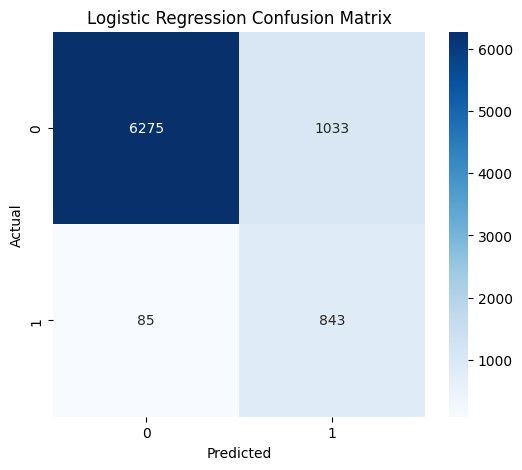

In [12]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Logistic Regression ROC Curve

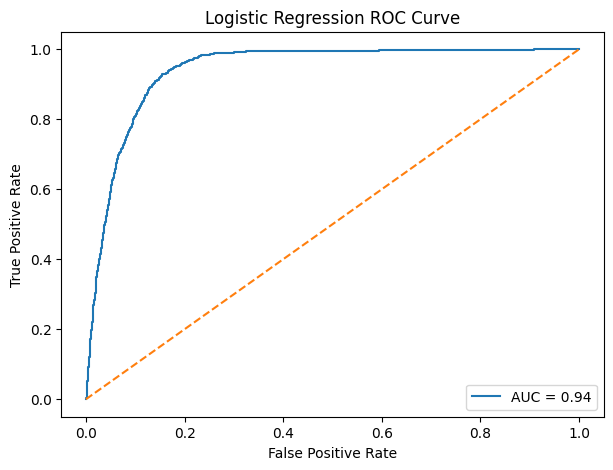

In [13]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

roc_auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(7,5))

plt.plot(fpr_log, tpr_log, label=f'AUC = {roc_auc_log:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Logistic Regression ROC Curve')

plt.legend()

plt.show()

## Random Forest Model

In [14]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

# Train Model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Evaluation
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

F1 Score: 0.5161716171617162

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.67      0.42      0.52       928

    accuracy                           0.91      8236
   macro avg       0.80      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236



### Random Forest Confusion Matrix

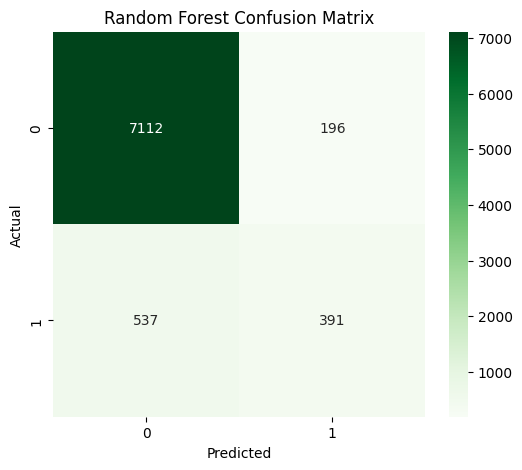

In [15]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Random Forest ROC Curve

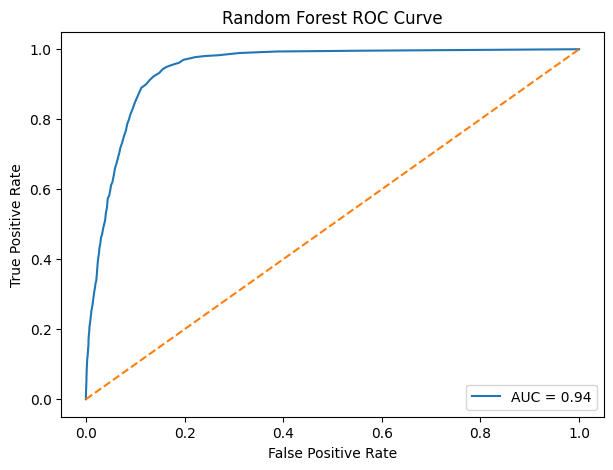

In [16]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7,5))

plt.plot(fpr_rf, tpr_rf, label=f'AUC = {roc_auc_rf:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Random Forest ROC Curve')

plt.legend()

plt.show()

# Model Comparison

In [17]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC AUC': [
        roc_auc_log,
        roc_auc_rf
    ]
})

display(comparison)

,Model,F1 Score,ROC AUC
0,Logistic Regression,0.601284,0.940276
1,Random Forest,0.516172,0.944057


## SHAP Explainability

### Transform Data for SHAP

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get Feature Names
feature_names = preprocessor.get_feature_names_out()

print("Total Features After Encoding:", len(feature_names))


Total Features After Encoding: 63


### Train Separate Random Forest Model for SHAP

In [19]:
rf_explain = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

rf_explain.fit(X_train_processed, y_train)

print("SHAP Model Trained Successfully")


SHAP Model Trained Successfully


# Create SHAP Explainer

In [20]:
explainer = shap.TreeExplainer(rf_explain)

# Convert Sparse Matrix to Dense
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

# Generate SHAP Values
shap_values = explainer.shap_values(X_test_dense)

print("SHAP Values Generated Successfully")

SHAP Values Generated Successfully


# SHAP Summary Plot

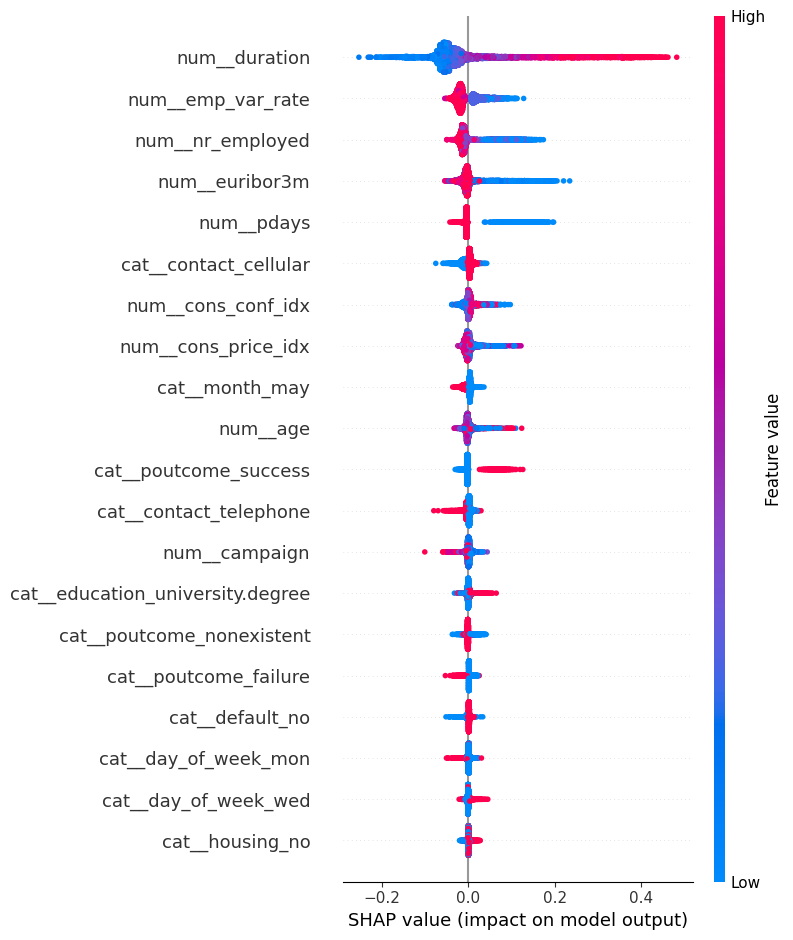

In [21]:
# Correct Handling for Binary Classification
if isinstance(shap_values, list):
    shap_data = shap_values[1]
else:
    shap_data = shap_values[:, :, 1]

shap.summary_plot(
    shap_data,
    X_test_dense,
    feature_names=feature_names
)

# Explain 5 Predictions Using SHAP Force Plot

Explaining Prediction 1


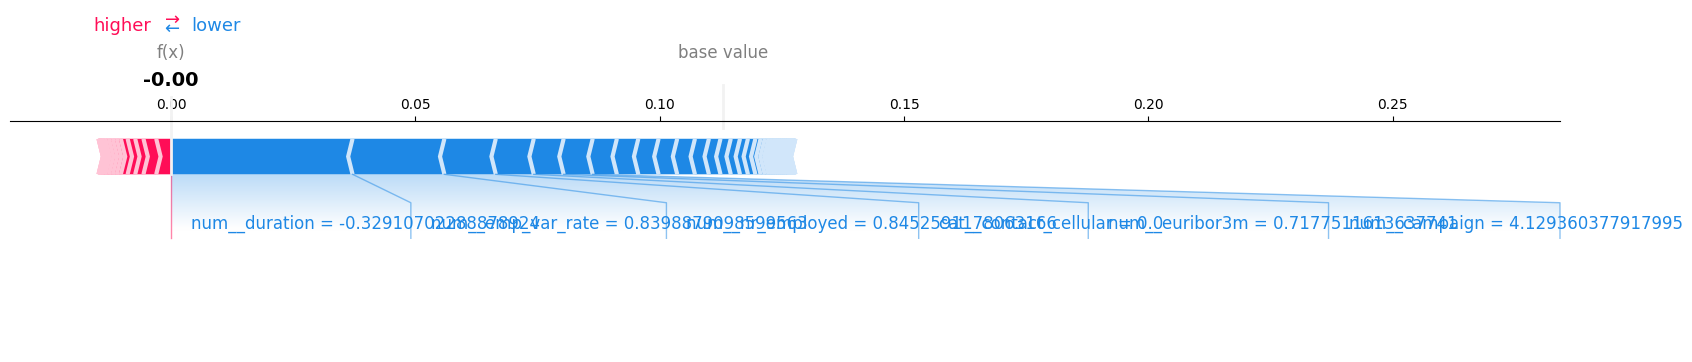

Explaining Prediction 2


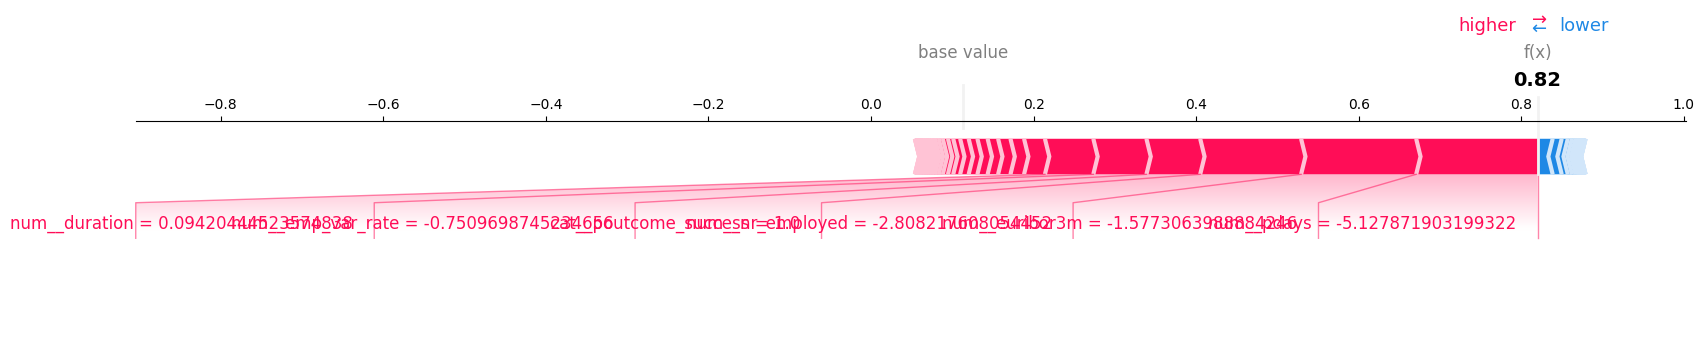

Explaining Prediction 3


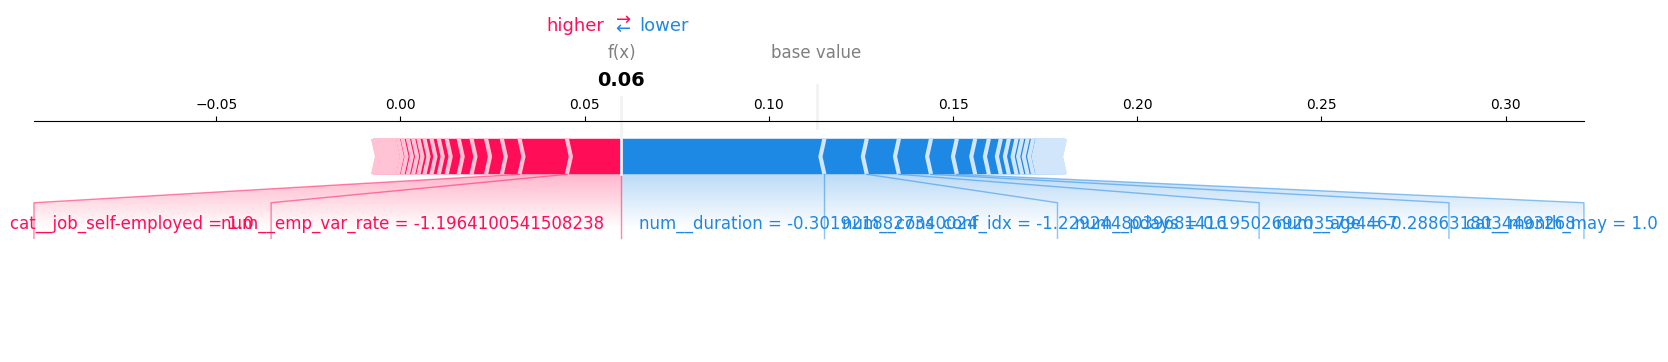

Explaining Prediction 4


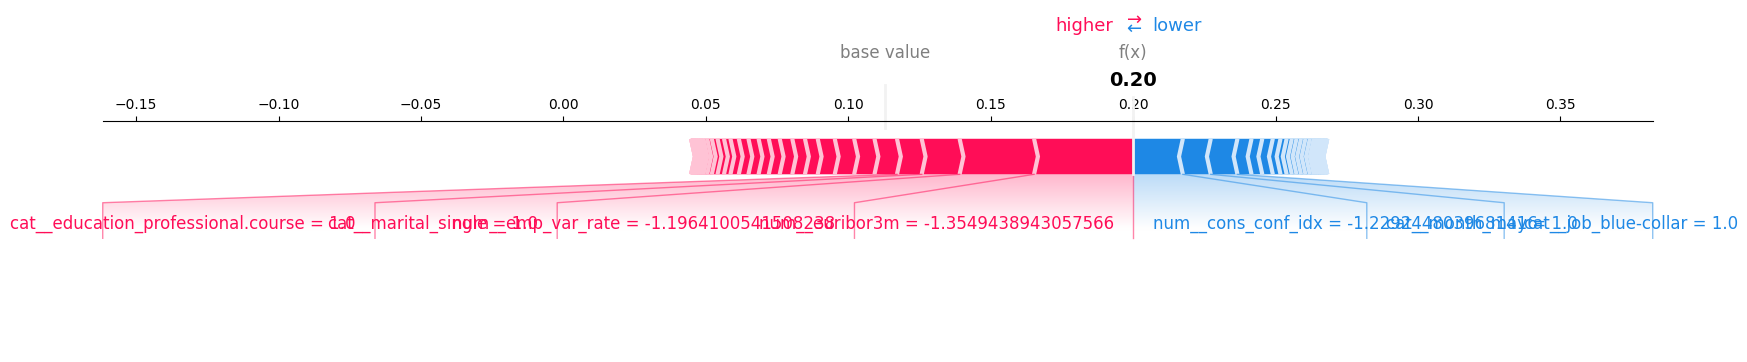

Explaining Prediction 5


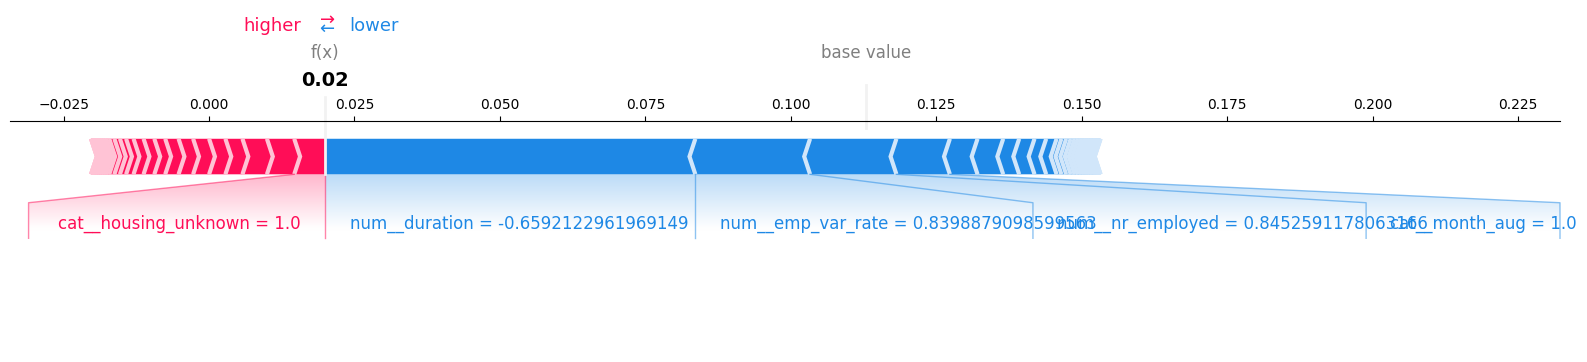

In [22]:
for i in range(5):

    print(f"Explaining Prediction {i+1}")

    if isinstance(shap_values, list):

        shap.force_plot(
            explainer.expected_value[1],
            shap_values[1][i],
            X_test_dense[i],
            feature_names=feature_names,
            matplotlib=True
        )

    else:

        shap.force_plot(
            explainer.expected_value[1],
            shap_values[i,:,1],
            X_test_dense[i],
            feature_names=feature_names,
            matplotlib=True
        )


# Feature Importance

,Feature,Importance
1,num__duration,0.278814
8,num__euribor3m,0.105915
0,num__age,0.080213
9,num__nr_employed,0.045571
2,num__campaign,0.039296
3,num__pdays,0.032610
5,num__emp_var_rate,0.023340
7,num__cons_conf_idx,0.023165
6,num__cons_price_idx,0.020901
62,cat__poutcome_success,0.015849


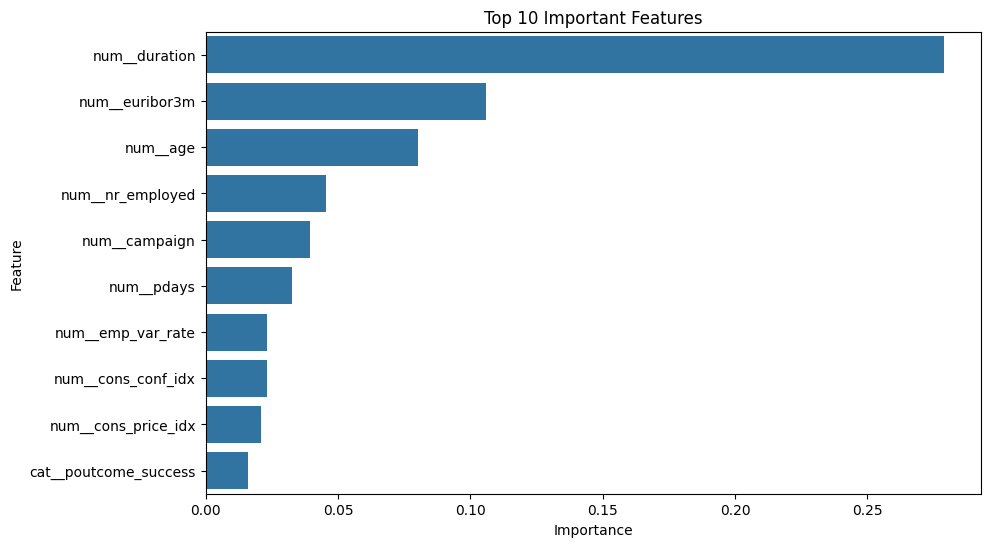

In [23]:
importances = rf_explain.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

display(feature_importance_df)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title('Top 10 Important Features')

plt.show()


# Conclusion

## Skills Gained
- Classification Modeling
- Feature Encoding
- Model Evaluation
- Explainable AI (SHAP)
- Customer Behavior Analysis

## Best Performing Model
Compare F1-Score and ROC-AUC values to identify the better model.
